# Fermentation Process Dimensionality Reduction using PCA

## Objective

This project applies Principal Component Analysis (PCA) to a synthetic
fermentation-process dataset containing multiple correlated biological
and process measurements.

The main objectives are:

- Understand the structure of fermentation-process data
- Identify correlations among process variables
- Build a Logistic Regression baseline model
- Apply Principal Component Analysis for dimensionality reduction
- Determine the number of principal components required to retain most
  of the information
- Train the same model using PCA-transformed features
- Compare model performance before and after PCA
- Interpret the contribution of original variables to the principal components

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

IMPORTING THE DATASET

In [2]:
data=pd.read_csv('Fermentation_dataset.csv')
data

,Sample_ID,Temperature_C,pH,Dissolved_Oxygen_pct,Agitation_RPM,Glucose_g_L,Biomass_g_L,Ethanol_g_L,CO2_mmol_L,Respiratory_Quotient,Pressure_kPa,Batch_Quality
0,FERM_0001,30.64,6.20,75.87,174.4,20.98,2.82,2.51,22.82,1.045,102.92,Good
1,FERM_0002,29.74,6.31,77.48,167.7,20.15,2.64,2.81,25.95,1.120,104.42,Good
2,FERM_0003,30.38,6.03,54.99,199.8,23.48,2.62,1.19,11.57,0.804,98.91,Needs_Review
3,FERM_0004,31.37,5.84,35.61,246.0,15.02,3.65,2.83,23.32,0.987,103.19,Good
4,FERM_0005,29.75,6.16,71.48,176.8,25.92,1.95,1.54,15.19,0.836,99.89,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
495,FERM_0496,30.75,6.37,82.31,197.6,21.79,2.94,2.00,16.79,0.912,101.30,Good
496,FERM_0497,29.06,6.57,95.00,145.2,23.30,1.88,2.78,23.91,1.097,104.16,Good
497,FERM_0498,29.61,6.33,77.32,169.7,23.32,2.51,2.76,19.98,0.948,102.73,Good
498,FERM_0499,29.17,6.52,85.61,151.0,31.67,1.41,1.54,11.92,0.848,99.64,Needs_Review


UNDERSTANDING THE DATASET

In [3]:
data.head()

,Sample_ID,Temperature_C,pH,Dissolved_Oxygen_pct,Agitation_RPM,Glucose_g_L,Biomass_g_L,Ethanol_g_L,CO2_mmol_L,Respiratory_Quotient,Pressure_kPa,Batch_Quality
0,FERM_0001,30.64,6.20,75.87,174.4,20.98,2.82,2.51,22.82,1.045,102.92,Good
1,FERM_0002,29.74,6.31,77.48,167.7,20.15,2.64,2.81,25.95,1.120,104.42,Good
2,FERM_0003,30.38,6.03,54.99,199.8,23.48,2.62,1.19,11.57,0.804,98.91,Needs_Review
3,FERM_0004,31.37,5.84,35.61,246.0,15.02,3.65,2.83,23.32,0.987,103.19,Good
4,FERM_0005,29.75,6.16,71.48,176.8,25.92,1.95,1.54,15.19,0.836,99.89,Good


In [4]:
data.shape

(500, 12)

In [5]:
data.describe()

,Temperature_C,pH,Dissolved_Oxygen_pct,Agitation_RPM,Glucose_g_L,Biomass_g_L,Ethanol_g_L,CO2_mmol_L,Respiratory_Quotient,Pressure_kPa
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,30.014540,6.208540,63.160720,184.196800,23.844140,2.399700,2.019440,18.159160,0.922020,101.354840
std,0.931743,0.220006,16.951575,29.515984,5.332432,0.701393,0.609874,4.668168,0.102642,1.877572
min,27.100000,5.500000,20.000000,120.000000,7.000000,1.000000,0.200000,8.000000,0.650000,96.000000
25%,29.437500,6.070000,51.285000,163.350000,20.215000,1.920000,1.650000,14.977500,0.856250,100.145000
50%,29.970000,6.210000,63.640000,183.450000,23.930000,2.365000,2.005000,17.920000,0.918500,101.345000
75%,30.660000,6.350000,75.625000,204.050000,27.527500,2.860000,2.410000,21.172500,0.987250,102.505000
max,33.220000,6.800000,95.000000,260.000000,34.000000,4.200000,4.080000,32.000000,1.200000,106.820000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Sample_ID             500 non-null    object 
 1   Temperature_C         500 non-null    float64
 2   pH                    500 non-null    float64
 3   Dissolved_Oxygen_pct  500 non-null    float64
 4   Agitation_RPM         500 non-null    float64
 5   Glucose_g_L           500 non-null    float64
 6   Biomass_g_L           500 non-null    float64
 7   Ethanol_g_L           500 non-null    float64
 8   CO2_mmol_L            500 non-null    float64
 9   Respiratory_Quotient  500 non-null    float64
 10  Pressure_kPa          500 non-null    float64
 11  Batch_Quality         500 non-null    object 
dtypes: float64(10), object(2)
memory usage: 47.0+ KB


In [7]:
#Missing values
data.isnull().sum()
print("Data has missing values:",data.isnull().sum().sum())

Data has missing values: 0


In [8]:
#Duplicate values
print("Data has duplicate values:",data.duplicated().sum().sum())

Data has duplicate values: 0


TARGET DISTRIBUTION

In [9]:
data['Batch_Quality'].value_counts()

Batch_Quality
Needs_Review    266
Good            234
Name: count, dtype: int64

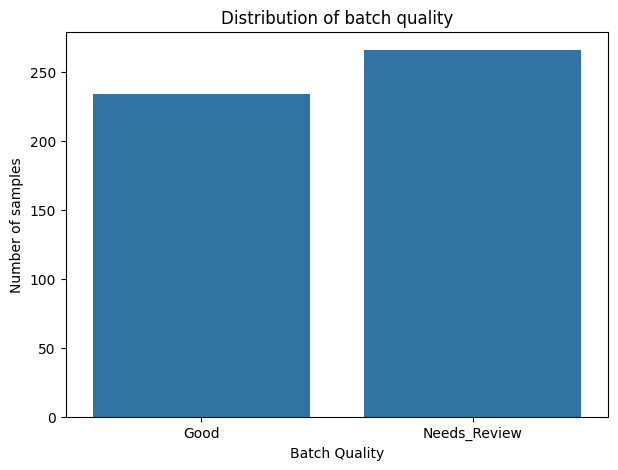

In [10]:
plt.figure(figsize=(7,5))
sns.countplot(data=data,x='Batch_Quality')
plt.title("Distribution of batch quality")
plt.xlabel("Batch Quality")
plt.ylabel("Number of samples")

plt.show()

In [11]:
#Identifying features and target
x=data.drop(columns=['Sample_ID','Batch_Quality'])
y=data['Batch_Quality']

In [12]:
x.head()

,Temperature_C,pH,Dissolved_Oxygen_pct,Agitation_RPM,Glucose_g_L,Biomass_g_L,Ethanol_g_L,CO2_mmol_L,Respiratory_Quotient,Pressure_kPa
0,30.64,6.20,75.87,174.4,20.98,2.82,2.51,22.82,1.045,102.92
1,29.74,6.31,77.48,167.7,20.15,2.64,2.81,25.95,1.120,104.42
2,30.38,6.03,54.99,199.8,23.48,2.62,1.19,11.57,0.804,98.91
3,31.37,5.84,35.61,246.0,15.02,3.65,2.83,23.32,0.987,103.19
4,29.75,6.16,71.48,176.8,25.92,1.95,1.54,15.19,0.836,99.89


EXPLORATRY DATA ANALYSIS

In [13]:
#Coorelation Matrix

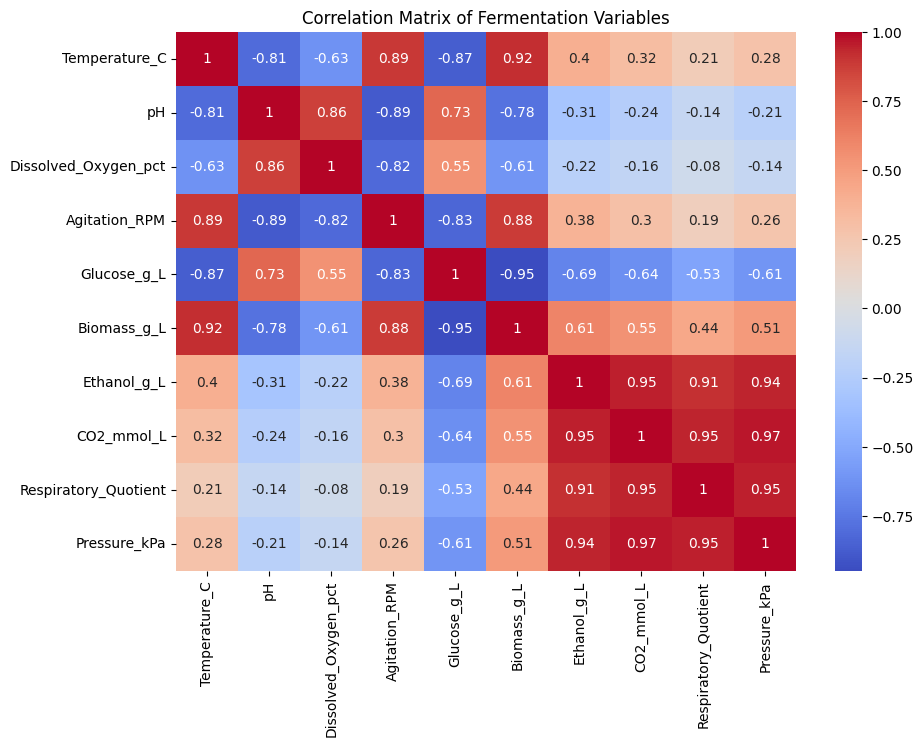

In [14]:
plt.figure(figsize=(10,7))
sns.heatmap(x.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Matrix of Fermentation Variables")
plt.show()

Several fermentation variables exhibit correlation, suggesting that some dimensions may contain overlapping information. PCA can potentially represent this information using fewer dimensions.

VISUALISING THE ORIGINAL DATA

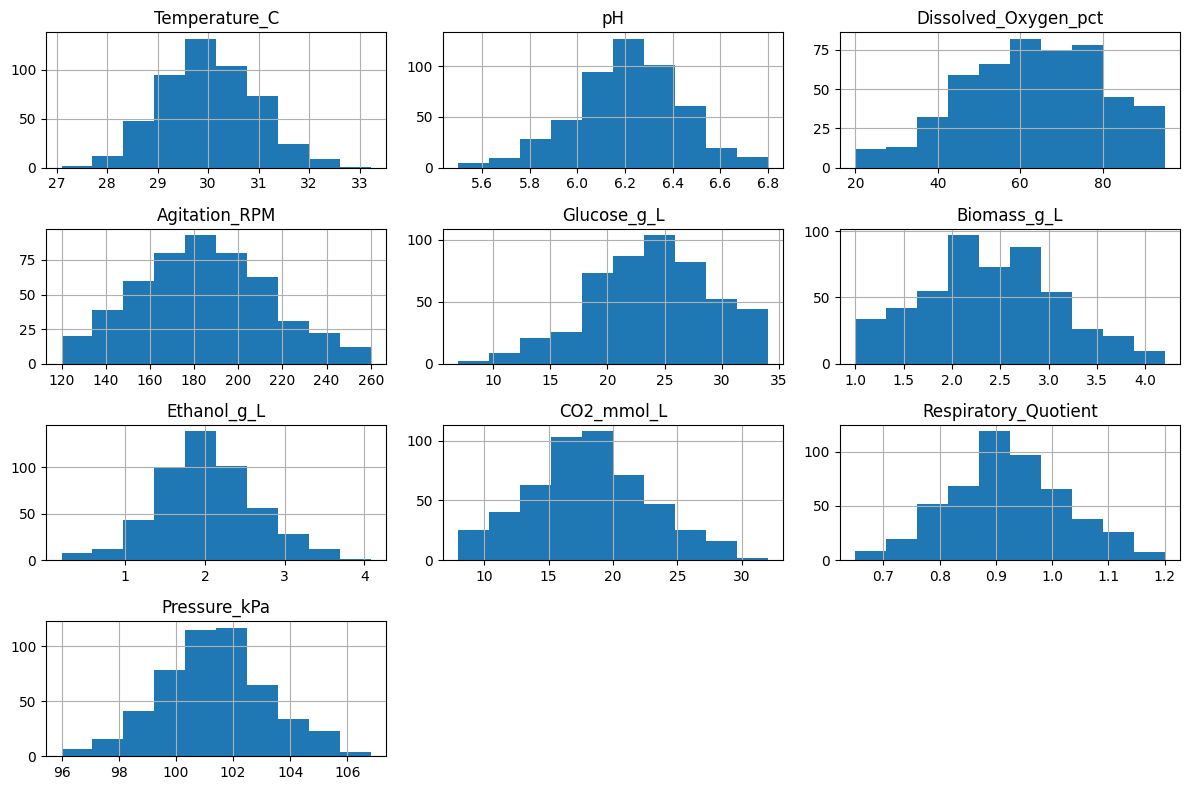

In [15]:
x.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

TRAIN-TEST-SPLIT

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
x_train.head()

,Temperature_C,pH,Dissolved_Oxygen_pct,Agitation_RPM,Glucose_g_L,Biomass_g_L,Ethanol_g_L,CO2_mmol_L,Respiratory_Quotient,Pressure_kPa
249,30.61,6.05,36.91,195.8,22.94,2.43,1.36,12.82,0.767,99.40
433,30.62,6.00,48.44,209.1,25.58,2.45,1.17,9.26,0.664,97.38
19,29.19,6.40,81.35,145.9,27.18,1.51,1.85,18.88,0.915,102.00
322,29.21,6.38,69.99,151.8,23.60,2.37,2.89,27.58,1.097,104.73
332,30.31,6.04,61.52,200.0,26.86,2.36,1.56,13.84,0.794,99.39


In [18]:
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (400, 10)
Testing data: (100, 10)


STANDARDIZATION

In [19]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

PART A — BASELINE MODEL
(This is the model performance before PCA)

In [20]:
#Training the model

In [21]:
from sklearn.linear_model import LogisticRegression
lr_before_pca=LogisticRegression()
lr_before_pca.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [22]:
#Predict and Calculate Accuracy

In [23]:
y_pred_before=lr_before_pca.predict(x_test_scaled)

In [24]:
from sklearn.metrics import accuracy_score
accuracy_before=accuracy_score(y_pred_before,y_test)
print("Accuracy before PCA:",accuracy_before * 100,"%")

Accuracy before PCA: 83.0 %


CLASSIFICATION REPORT BEFORE PCA

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_before))

              precision    recall  f1-score   support

        Good       0.89      0.77      0.83        53
Needs_Review       0.78      0.89      0.83        47

    accuracy                           0.83       100
   macro avg       0.83      0.83      0.83       100
weighted avg       0.84      0.83      0.83       100



CONFUSION MATRIX BEFORE PCA

In [26]:
from sklearn.metrics import confusion_matrix

In [27]:
cm_before=confusion_matrix(y_test,y_pred_before)
cm_before

array([[41, 12],
       [ 5, 42]])

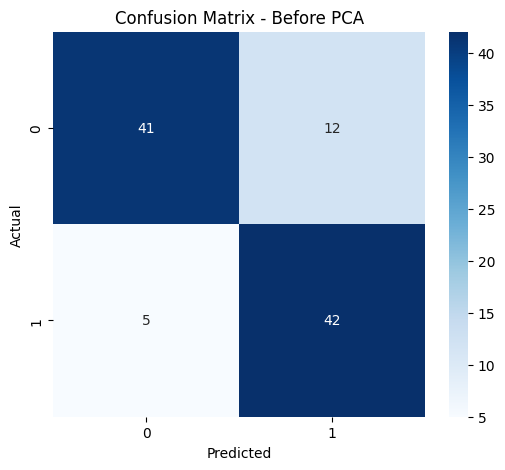

In [28]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_before,annot=True,fmt="d",cmap="Blues")

plt.title("Confusion Matrix - Before PCA")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

PART B — PCA

In [29]:
from sklearn.decomposition import PCA

In [30]:
#PCA with all components
pca_all=PCA()
x_train_all=pca_all.fit_transform(x_train_scaled)
x_test_all=pca_all.transform(x_test_scaled)

EXPLAINED VARIANCE RATIO

In [31]:
explained_variance=pca_all.explained_variance_ratio_
explained_variance

array([0.63957695, 0.27312831, 0.04853022, 0.00990406, 0.00648034,
       0.00627883, 0.00530139, 0.00411362, 0.00367795, 0.00300832])

EXPLAINED VARIANCE TABLE

In [32]:
variance_df=pd.DataFrame({
    "Principal Component":[
        f"PC{i}" for i in range(1,len(explained_variance)+1)],
    "Explained Variance":explained_variance,
    "Explained Variance (%)":explained_variance*100,
    "Cumulative Variance":np.cumsum(explained_variance)*100})
variance_df

,Principal Component,Explained Variance,Explained Variance (%),Cumulative Variance
0,PC1,0.639577,63.957695,63.957695
1,PC2,0.273128,27.312831,91.270526
2,PC3,0.048530,4.853022,96.123548
3,PC4,0.009904,0.990406,97.113954
4,PC5,0.006480,0.648034,97.761989
5,PC6,0.006279,0.627883,98.389872
6,PC7,0.005301,0.530139,98.920011
7,PC8,0.004114,0.411362,99.331373
8,PC9,0.003678,0.367795,99.699168
9,PC10,0.003008,0.300832,100.000000


CUMULATIVE EXPLAINED VARIANCE

In [33]:
cumulative_variance=np.cumsum(explained_variance)
cumulative_variance

array([0.63957695, 0.91270526, 0.96123548, 0.97113954, 0.97761989,
       0.98389872, 0.98920011, 0.99331373, 0.99699168, 1.        ])

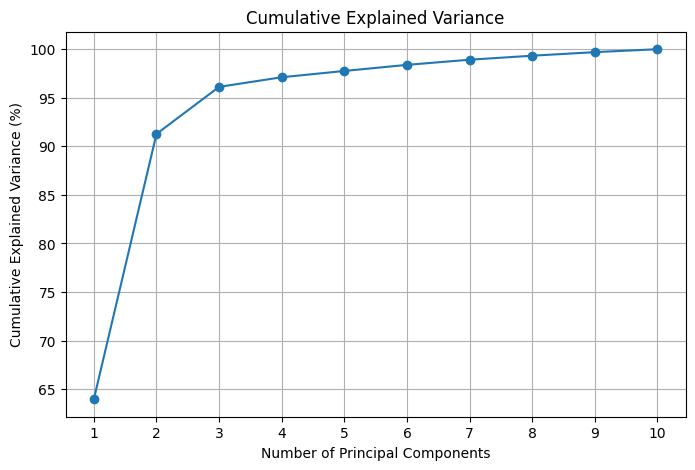

In [34]:
#PLotting the Cumulative Variance
plt.figure(figsize=(8,5))
plt.plot(range(1,len(cumulative_variance)+1),cumulative_variance*100,marker='o')

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance")

plt.xticks(range(1, len(cumulative_variance) + 1))

plt.grid()
plt.show()

PLOTTING THE EXPLAINED VARIANCE

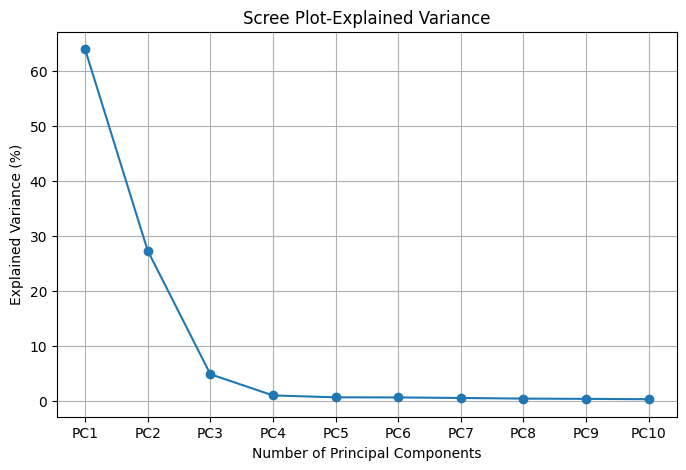

In [35]:
plt.figure(figsize=(8,5))
plt.plot(range(1,len(explained_variance)+1),explained_variance*100,marker='o')

plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot-Explained Variance")

plt.xticks(ticks=range(1, len(explained_variance) + 1),labels=[f'PC{i}' for i in range(1,len(explained_variance)+1)])

plt.grid()
plt.show()

FINDING OPTIMAL NUMBER OF PRINCIPAL COMPONENTS

In [36]:
n_components=np.argmax(cumulative_variance>=0.90)+1
print("Number of components required for 90% variance:",n_components)

Number of components required for 90% variance: 2


APPLYING PCA WITH n_components=2

In [37]:
pca=PCA(n_components=2)
x_train_pca=pca.fit_transform(x_train_scaled)
x_test_pca=pca.transform(x_test_scaled)

In [38]:
#Compare Dimensions
print("Original Features:",x_train_scaled.shape[1])
print("PCA Updated Features:",x_train_pca.shape[1])

Original Features: 10
PCA Updated Features: 2


In [39]:
#PCA Explained Variance After Selection
print("Percentage of data retained:",pca.explained_variance_ratio_.sum()*100,"%")

Percentage of data retained: 91.27052621185308 %


PART C — VISUALIZE PCA SPACE

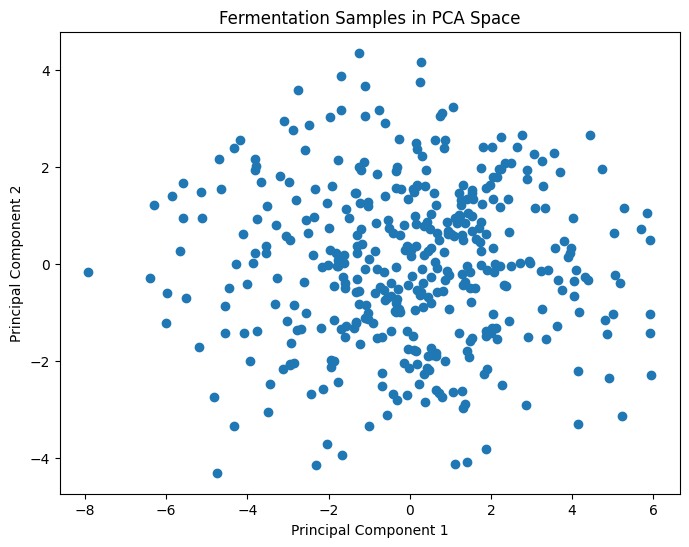

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(x=x_train_pca[:,0],y=x_train_pca[:,1])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Fermentation Samples in PCA Space")

plt.show()

PART D — PCA LOADINGS

In [41]:
pca.components_

array([[-0.32702964,  0.30302831,  0.25909217, -0.32877524,  0.37577814,
        -0.36925631, -0.32032397, -0.30221642, -0.26405198, -0.29116739],
       [-0.26494693,  0.33508831,  0.33552031, -0.31036285,  0.05286952,
        -0.13418343,  0.32839976,  0.37532095,  0.42872962,  0.39407904]])

In [42]:
#Calculating Loadings
loadings=pd.DataFrame(
    pca.components_.T,columns=[f"PC{i}" for i in range(1,n_components+1)],index=x.columns)
loadings

,PC1,PC2
Temperature_C,-0.327030,-0.264947
pH,0.303028,0.335088
Dissolved_Oxygen_pct,0.259092,0.335520
Agitation_RPM,-0.328775,-0.310363
Glucose_g_L,0.375778,0.052870
Biomass_g_L,-0.369256,-0.134183
Ethanol_g_L,-0.320324,0.328400
CO2_mmol_L,-0.302216,0.375321
Respiratory_Quotient,-0.264052,0.428730
Pressure_kPa,-0.291167,0.394079


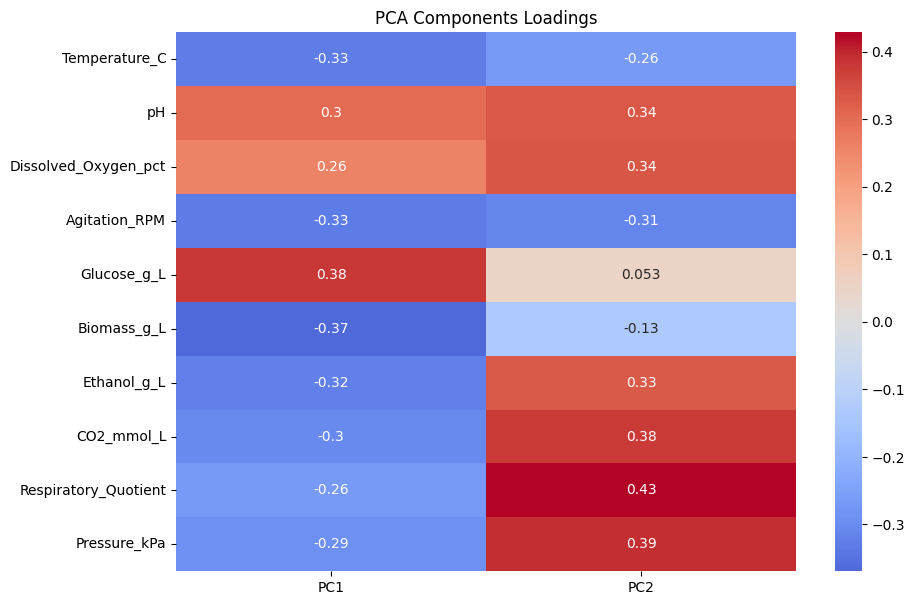

In [43]:
#Loading Heatmap
plt.figure(figsize=(10,7))

sns.heatmap(loadings,annot=True,cmap="coolwarm",center=0)

plt.title("PCA Components Loadings")
plt.show()

PART E — MODEL AFTER PCA

In [44]:
#Training PCA updated data with Logistic Regression

In [45]:
lr_after_pca=LogisticRegression()

In [46]:
lr_after_pca.fit(x_train_pca,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [47]:
y_pred_after=lr_after_pca.predict(x_test_pca)

In [48]:
accuracy_after=accuracy_score(y_pred_after,y_test)
print("Accuracy after PCA:",accuracy_after * 100,"%")

Accuracy after PCA: 76.0 %


CLASSIFICATION REPORT AFTER PCA

In [49]:
print(classification_report(y_test,y_pred_after))

              precision    recall  f1-score   support

        Good       0.82      0.70      0.76        53
Needs_Review       0.71      0.83      0.76        47

    accuracy                           0.76       100
   macro avg       0.77      0.76      0.76       100
weighted avg       0.77      0.76      0.76       100



CONFUSION MATRIX AFTER PCA

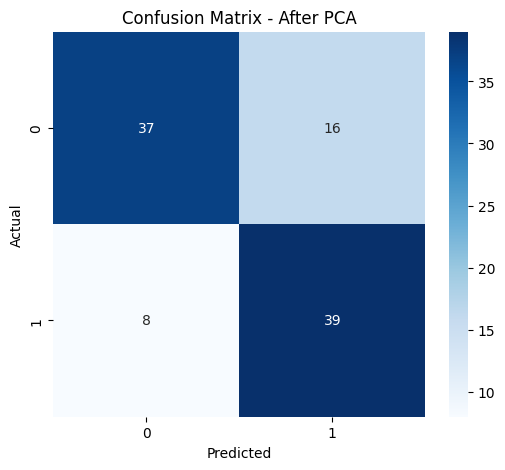

In [50]:
cm_after=confusion_matrix(y_test,y_pred_after)

#PLotting the Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_after,annot=True,fmt="d",cmap="Blues")

plt.title("Confusion Matrix - After PCA")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

PART F — BEFORE vs AFTER PCA

In [53]:
comparison=pd.DataFrame({
    "Models":["Logistic Regression","Logistic Regression+PCA"],
    "Number of features":[x_train_scaled.shape[1],x_train_pca.shape[1]],
    "Accuracy(%)":[accuracy_before*100,accuracy_after*100]})
comparison

,Models,Number of features,Accuracy(%)
0,Logistic Regression,10,83.0
1,Logistic Regression+PCA,2,76.0


ACCURACY COMPARISON PLOT

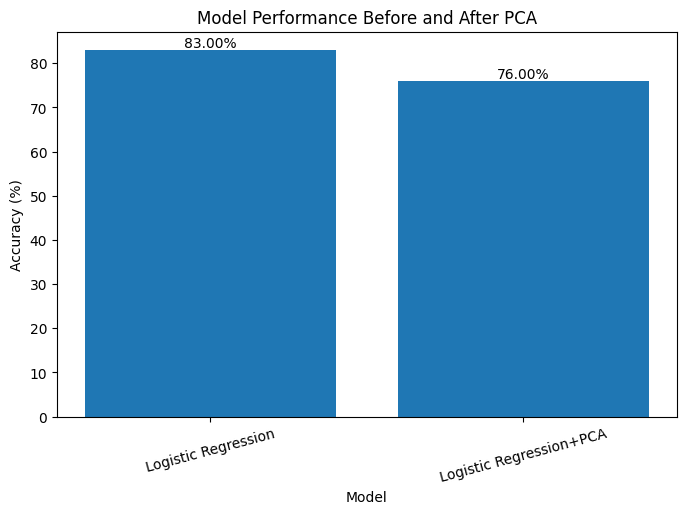

In [56]:
plt.figure(figsize=(8,5))
bars=plt.bar(comparison['Models'],comparison['Accuracy(%)'])
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Model Performance Before and After PCA")
plt.xticks(rotation=15)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,bar.get_height(),
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom"
    )

plt.show()

In [60]:
#Change in accuracy score
change=accuracy_before-accuracy_after
print("Change in accuracy:",change*100,"%")

Change in accuracy: 6.999999999999995 %


PART G — FINAL SUMMARY TABLE

In [62]:
summary = pd.DataFrame({
    "Metric": [
        "Original Features",
        "PCA Features",
        "Variance Retained",
        "Accuracy Before PCA",
        "Accuracy After PCA",
    ],
    
    "Value": [
        x_train_scaled.shape[1],
        x_train_pca.shape[1],
        f"{pca.explained_variance_ratio_.sum() * 100:.2f}%",
        f"{accuracy_before * 100:.2f}%",
        f"{accuracy_after * 100:.2f}%",
    ]
})

summary

,Metric,Value
0,Original Features,10
1,PCA Features,2
2,Variance Retained,91.27%
3,Accuracy Before PCA,83.00%
4,Accuracy After PCA,76.00%


## Conclusion

In this project, Principal Component Analysis (PCA) was applied to
10 fermentation-process variables to investigate dimensionality
reduction while retaining important information from the dataset.

The original feature space was reduced from **10 features to 2
principal components**, with the selected components retaining
approximately **91.27% of the total variance**.

A Logistic Regression model was first trained using the original
standardized features and achieved an accuracy of **83%**.

The same Logistic Regression algorithm was then trained using the
PCA-transformed features and achieved an accuracy of **76%**.

The comparison demonstrates the effect of dimensionality reduction
on predictive performance. PCA provided a lower-dimensional
representation of the fermentation data while retaining a substantial
amount of its variance.

The PCA loadings were also analyzed to understand which original
fermentation variables contributed most strongly to the principal
components.

Overall, this project demonstrates how PCA can be used as a
dimensionality-reduction technique before applying machine learning
models to correlated, high-dimensional data.